In [1]:
!pip install optuna catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 8.2 MB/s eta 0:00:00


In [2]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve, classification_report
)
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import optuna
import shap
from scipy.stats import friedmanchisquare, wilcoxon

RANDOM_STATE = 42
print("Libraries imported successfully.")


Libraries imported successfully.


In [3]:
# ============================================
# 2. LOAD DATASET
# ============================================

df = pd.read_csv("chimefrbcat2_dataset.csv")

print("Dataset Shape :", df.shape)

df.head()

Dataset Shape : (5045, 60)


,tns_name,previous_name,repeater_name,event_id,sub_num,ra,ra_err,dec,dec_err,ra_dec_notes,...,chi_sq,dof,flag_frac,notes_fitb,intrachan_flag,excluded_flag,sidelobe_flag,citizen_science_flag,catalog1_flag,catalog1_param_flag
0,FRB20180725A,180725.J0613+67,NaN,9386707,0,93.702524,0.006083,64.758182,0.022299,NaN,...,1830540.877,1831566,0.309937,NaN,0,1,0,0,1,0
1,FRB20180727A,180727.J1311+26,NaN,9461009,0,197.716285,0.127518,26.421681,0.260983,NaN,...,1863954.273,1864128,0.297668,NaN,0,1,0,0,1,1
2,FRB20180729A,180729.J1316+55,NaN,9541535,0,199.402427,0.120463,55.576962,0.084350,NaN,...,1864163.924,1902036,0.283386,NaN,0,1,0,0,1,0
3,FRB20180729B,180729.J0558+56,NaN,9564770,0,89.928581,0.266272,56.495399,0.239360,NaN,...,2022652.182,2023374,0.237671,NaN,0,1,0,0,1,1
4,FRB20180730A,180730.J0353+87,NaN,9574801,0,268.840585,0.026281,85.426980,0.032659,NaN,...,2022049.512,2029853,0.235229,NaN,0,1,0,0,1,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5045 entries, 0 to 5044
Data columns (total 60 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tns_name              5045 non-null   object 
 1   previous_name         40 non-null     object 
 2   repeater_name         1282 non-null   object 
 3   event_id              5045 non-null   int64  
 4   sub_num               5045 non-null   int64  
 5   ra                    5008 non-null   float64
 6   ra_err                5008 non-null   float64
 7   dec                   5008 non-null   float64
 8   dec_err               5008 non-null   float64
 9   ra_dec_notes          38 non-null     object 
 10  gl                    5008 non-null   float64
 11  gb                    5008 non-null   float64
 12  exp_up                5007 non-null   float64
 13  exp_up_err            5007 non-null   float64
 14  exp_low               5007 non-null   float64
 15  exp_low_err          

In [5]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

,0
ra_dec_notes,5007
previous_name,5005
notes_fitb,4911
exp_notes,4605
fluence_notes,4568
repeater_name,3763
low_ft_68,3064
low_ft_95,3064
scat_time_err,3049
flux_err,518


In [6]:
print("Before:", len(df))

df = df.drop_duplicates()

print("After :", len(df))

Before: 5045
After : 5045


In [7]:
# ============================================
# 3. CREATE BINARY TARGET
# 0 = Non-repeating FRB, 1 = Repeating FRB
# ============================================
if "repeater_name" not in df.columns:
    raise KeyError("The dataset must contain 'repeater_name' to create the target.")

df["Target"] = df["repeater_name"].notna().astype(int)

# Preserve a readable event identifier for the final prediction table.
event_id_candidates = ["tns_name", "previous_name", "event_name", "frb_name", "name"]
event_id_col = next((c for c in event_id_candidates if c in df.columns), None)
if event_id_col is None:
    df["FRB_event"] = "FRB_" + df.index.astype(str)
    event_id_col = "FRB_event"

print(df["Target"].value_counts())
print(df["Target"].value_counts(normalize=True).rename("Proportion"))


Target
0    3763
1    1282
Name: count, dtype: int64
Target
0    0.745887
1    0.254113
Name: Proportion, dtype: float64


In [8]:
# ============================================
# 4. PHYSICALLY MEANINGFUL FEATURE SETS
# ============================================
# Core 17-feature set requested for tree-based models.
core_features = [
    "dm_fitb", "dm_exc_ne2001", "dm_exc_ymw16", "snr_fitb",
    "bonsai_snr", "bonsai_dm", "fluence", "flux", "scat_time",
    "peak_freq", "high_freq", "low_freq", "sp_idx", "sp_run",
    "bc_width", "gb", "gl"
]

# Additional useful variables requested.
additional_features = ["exp_up", "exp_low", "mjd_inf", "ra", "dec"]

expanded_features = core_features + additional_features

available_core = [c for c in core_features if c in df.columns]
available_additional = [c for c in additional_features if c in df.columns]
available_expanded = available_core + available_additional
missing_requested = [c for c in expanded_features if c not in df.columns]

print(f"Core features available: {len(available_core)}/{len(core_features)}")
print(f"Additional features available: {len(available_additional)}/{len(additional_features)}")
print("Selected columns:", available_expanded)
if missing_requested:
    print("Requested columns absent from this CSV:", missing_requested)

if len(available_expanded) < 2:
    raise ValueError("Too few requested predictors are available in the dataset.")


Core features available: 17/17
Additional features available: 5/5
Selected columns: ['dm_fitb', 'dm_exc_ne2001', 'dm_exc_ymw16', 'snr_fitb', 'bonsai_snr', 'bonsai_dm', 'fluence', 'flux', 'scat_time', 'peak_freq', 'high_freq', 'low_freq', 'sp_idx', 'sp_run', 'bc_width', 'gb', 'gl', 'exp_up', 'exp_low', 'mjd_inf', 'ra', 'dec']


In [9]:
# IMPORTANT: prevent target leakage.
# 'repeater_name' is used only to create Target and must never be a predictor.
leakage_columns = ["repeater_name", "Target"]
print("Leakage columns excluded:", leakage_columns)


Leakage columns excluded: ['repeater_name', 'Target']


In [10]:
# Convert selected predictors to numeric.
# Non-numeric strings become NaN and are handled by median imputation later.
feature_data = df[available_expanded].copy()
for col in feature_data.columns:
    feature_data[col] = pd.to_numeric(feature_data[col], errors="coerce")

print(feature_data.dtypes)
print("Missing values in selected features:")
display(feature_data.isna().sum().sort_values(ascending=False).to_frame("Missing"))


dm_fitb          float64
dm_exc_ne2001    float64
dm_exc_ymw16     float64
snr_fitb         float64
bonsai_snr       float64
bonsai_dm        float64
fluence          float64
flux             float64
scat_time        float64
peak_freq        float64
high_freq        float64
low_freq         float64
sp_idx           float64
sp_run           float64
bc_width         float64
gb               float64
gl               float64
exp_up           float64
exp_low          float64
mjd_inf          float64
ra               float64
dec              float64
dtype: object
Missing values in selected features:


,Missing
flux,518
fluence,518
peak_freq,84
scat_time,84
dm_fitb,84
snr_fitb,84
bc_width,84
low_freq,84
sp_idx,84
sp_run,84


In [11]:
# Remove selected features that are completely missing or constant.
all_missing_cols = [c for c in feature_data.columns if feature_data[c].isna().all()]
constant_cols = [c for c in feature_data.columns if feature_data[c].nunique(dropna=True) <= 1]
drop_unusable = sorted(set(all_missing_cols + constant_cols))

if drop_unusable:
    print("Dropping unusable selected columns:", drop_unusable)
    feature_data = feature_data.drop(columns=drop_unusable)

selected_features = feature_data.columns.tolist()
print(f"Final expanded feature count: {len(selected_features)}")
print(selected_features)


Final expanded feature count: 22
['dm_fitb', 'dm_exc_ne2001', 'dm_exc_ymw16', 'snr_fitb', 'bonsai_snr', 'bonsai_dm', 'fluence', 'flux', 'scat_time', 'peak_freq', 'high_freq', 'low_freq', 'sp_idx', 'sp_run', 'bc_width', 'gb', 'gl', 'exp_up', 'exp_low', 'mjd_inf', 'ra', 'dec']


In [12]:
# Prepare predictors and target while retaining original row indices.
X_raw = feature_data.copy()
y = df.loc[X_raw.index, "Target"].copy()

print("X shape:", X_raw.shape)
print("y shape:", y.shape)


X shape: (5045, 22)
y shape: (5045,)


In [13]:
# Stratified hold-out split.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.20,
    stratify=y,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("Training set:", X_train_raw.shape)
print("Testing set :", X_test_raw.shape)


Training set: (4036, 22)
Testing set : (1009, 22)


In [14]:
# Fit imputation only on training data to avoid data leakage.
imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train_raw),
    columns=X_train_raw.columns,
    index=X_train_raw.index
)
X_test = pd.DataFrame(
    imputer.transform(X_test_raw),
    columns=X_test_raw.columns,
    index=X_test_raw.index
)

print("Remaining missing values:", X_train.isna().sum().sum() + X_test.isna().sum().sum())


Remaining missing values: 0


In [15]:
# Tree-based models do not require standardization.
# Keeping original physical scales also makes feature-importance interpretation clearer.
print("Features used by the optimized models:")
print(X_train.columns.tolist())


Features used by the optimized models:
['dm_fitb', 'dm_exc_ne2001', 'dm_exc_ymw16', 'snr_fitb', 'bonsai_snr', 'bonsai_dm', 'fluence', 'flux', 'scat_time', 'peak_freq', 'high_freq', 'low_freq', 'sp_idx', 'sp_run', 'bc_width', 'gb', 'gl', 'exp_up', 'exp_low', 'mjd_inf', 'ra', 'dec']


In [16]:
# Class distribution check.
print("Training distribution")
display(y_train.value_counts().rename(index={0:"Non-repeating",1:"Repeating"}).to_frame("Count"))
print("Testing distribution")
display(y_test.value_counts().rename(index={0:"Non-repeating",1:"Repeating"}).to_frame("Count"))


Training distribution


,Count
Target,
Non-repeating,3010
Repeating,1026


Testing distribution


,Count
Target,
Non-repeating,753
Repeating,256


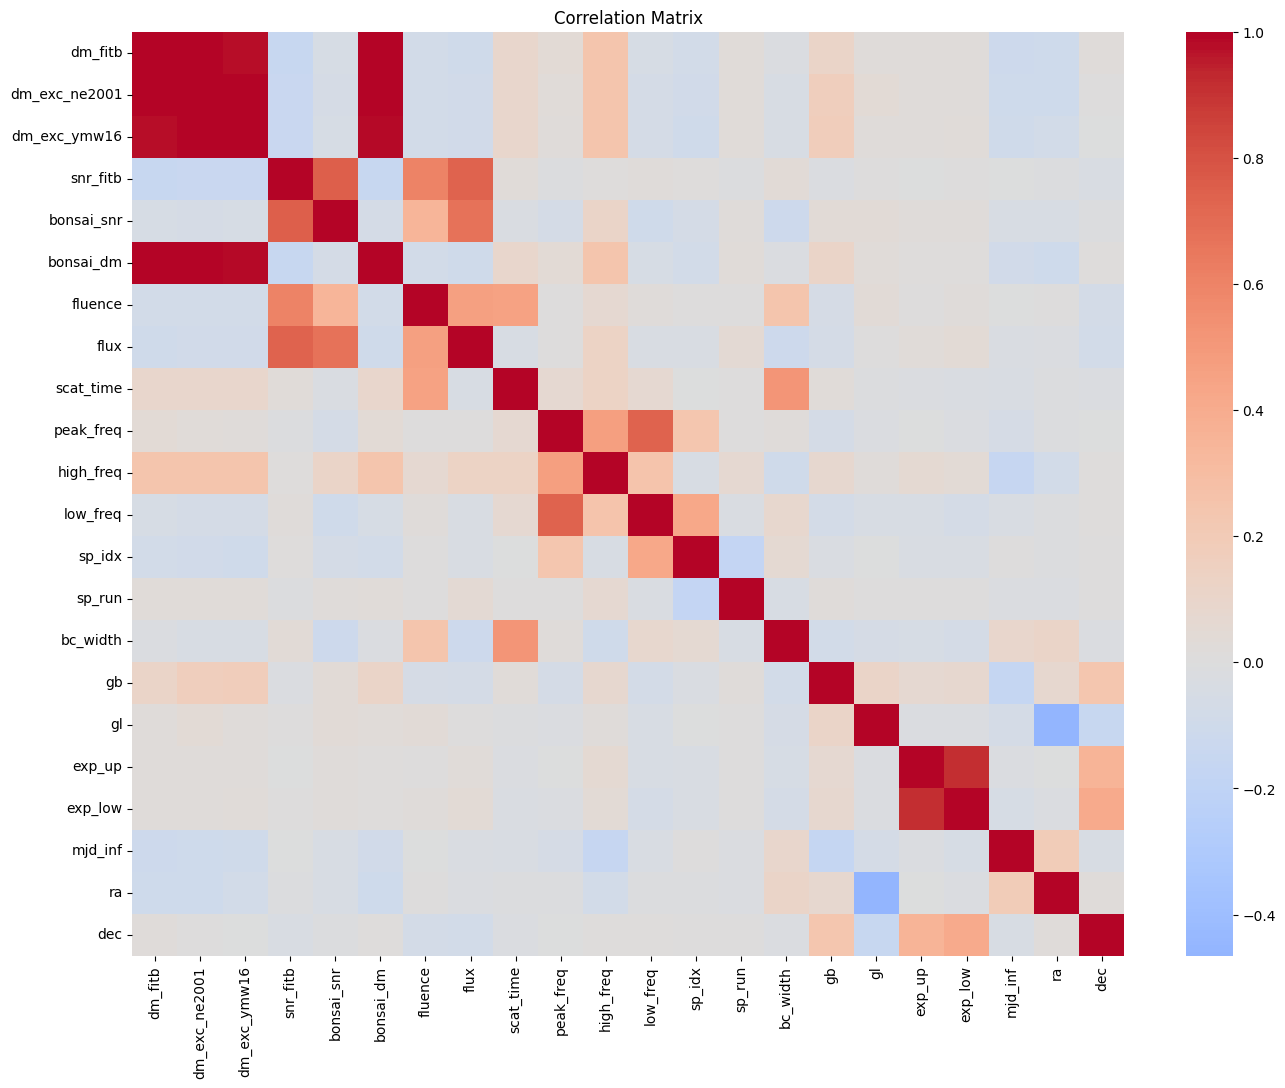

In [19]:
plt.figure(figsize=(16,12))

corr = X_raw.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

In [20]:
# ============================================
# 5. CORE vs EXPANDED FEATURE-SET COMPARISON
# ============================================
# A fixed LightGBM configuration gives a fair preliminary comparison.
# Final reported model scores below come from the optimized models.

def evaluate_feature_set(feature_names, label):
    cols = [c for c in feature_names if c in X_raw.columns]
    if len(cols) < 2:
        return None

    imp = SimpleImputer(strategy="median")
    Xtr = imp.fit_transform(X_train_raw[cols])
    Xte = imp.transform(X_test_raw[cols])

    model = LGBMClassifier(
        n_estimators=250, learning_rate=0.05, num_leaves=31,
        class_weight="balanced", random_state=RANDOM_STATE,
        n_jobs=-1, verbosity=-1
    )
    model.fit(Xtr, y_train)
    pred = model.predict(Xte)
    prob = model.predict_proba(Xte)[:, 1]
    return {
        "Feature Set": label,
        "No. Features": len(cols),
        "Accuracy": accuracy_score(y_test, pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1-score": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, prob),
        "PR-AUC": average_precision_score(y_test, prob)
    }

feature_set_results = []
core_result = evaluate_feature_set(available_core, "Core requested features")
expanded_result = evaluate_feature_set(selected_features, "Core + additional features")
if core_result: feature_set_results.append(core_result)
if expanded_result: feature_set_results.append(expanded_result)

feature_set_comparison = pd.DataFrame(feature_set_results).round(4)
display(feature_set_comparison)
feature_set_comparison.to_csv("Feature_Set_Comparison.csv", index=False)


,Feature Set,No. Features,Accuracy,Balanced Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Core requested features,17,0.9653,0.9458,0.9547,0.9062,0.9299,0.9886,0.9783
1,Core + additional features,22,0.9762,0.9609,0.9754,0.9297,0.9520,0.9920,0.9859


In [21]:
# The expanded available feature set is used for all five optimized models below.
# X_train, X_test, y_train and y_test are already prepared above.


In [22]:
print("Final modeling matrix:", X_train.shape, X_test.shape)


Final modeling matrix: (4036, 22) (1009, 22)


In [23]:
outer_cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)

inner_cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)

In [24]:
for fold, (train_idx, valid_idx) in enumerate(outer_cv.split(X_train, y_train), 1):

    X_outer_train = X_train.iloc[train_idx]
    X_outer_valid = X_train.iloc[valid_idx]

    y_outer_train = y_train.iloc[train_idx]
    y_outer_valid = y_train.iloc[valid_idx]

    print(f"\nFold {fold}")

    print("Training :", X_outer_train.shape)

    print("Validation :", X_outer_valid.shape)


Fold 1
Training : (3228, 22)
Validation : (808, 22)

Fold 2
Training : (3229, 22)
Validation : (807, 22)

Fold 3
Training : (3229, 22)
Validation : (807, 22)

Fold 4
Training : (3229, 22)
Validation : (807, 22)

Fold 5
Training : (3229, 22)
Validation : (807, 22)


In [25]:
from sklearn.model_selection import cross_val_score
from sklearn.base import clone

In [26]:
def rf_objective(trial):

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators",
            100,
            300,
            step=50
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            5,
            30
        ),

        "min_samples_split": trial.suggest_int(
            "min_samples_split",
            2,
            10
        ),

        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf",
            1,
            5
        ),

        "max_features": trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2"]
        ),

        "bootstrap": trial.suggest_categorical(
            "bootstrap",
            [True, False]
        ),

        "criterion": trial.suggest_categorical(
            "criterion",
            ["gini", "entropy"]
        ),

        "class_weight": trial.suggest_categorical(
            "class_weight",
            [None, "balanced"]
        ),

        "random_state":42,

        "n_jobs":-1
    }

    model = RandomForestClassifier(**params)

    score = cross_val_score(

        model,

        X_train,

        y_train,

        cv=inner_cv,

        scoring="f1",

        n_jobs=-1

    ).mean()

    return score

In [27]:
rf_accuracy = []
rf_precision = []
rf_recall = []
rf_f1 = []
rf_auc = []

best_params_list = []

In [28]:
study = optuna.create_study(

    direction="maximize",

    pruner=optuna.pruners.MedianPruner()

)

study.optimize(

    rf_objective,

    n_trials=10,          # Increase to 50–100 for final paper

    show_progress_bar=True

)

[I 2026-08-03 07:26:17,680] A new study created in memory with name: no-name-c69e5d98-30be-400d-a6ed-d0e900baebeb


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-08-03 07:26:47,704] Trial 0 finished with value: 0.8904364685720051 and parameters: {'n_estimators': 300, 'max_depth': 19, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'entropy', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8904364685720051.
[I 2026-08-03 07:27:02,845] Trial 1 finished with value: 0.8830147221306918 and parameters: {'n_estimators': 250, 'max_depth': 29, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'entropy', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8904364685720051.
[I 2026-08-03 07:27:15,541] Trial 2 finished with value: 0.8829247171415127 and parameters: {'n_estimators': 200, 'max_depth': 26, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': True, 'criterion': 'entropy', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8904364685720051.
[I 2026-08-03 07:27:20,972] Trial

In [29]:
print("="*50)

print("Best F1 Score")

print(study.best_value)

print("\nBest Parameters")

print(study.best_params)

Best F1 Score
0.8904364685720051

Best Parameters
{'n_estimators': 300, 'max_depth': 19, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'entropy', 'class_weight': 'balanced'}


In [30]:
best_params = study.best_params

best_params["random_state"] = 42
best_params["n_jobs"] = -1

rf_model = RandomForestClassifier(

    **best_params

)

rf_model.fit(

    X_train,

    y_train
)

RandomForestClassifier(bootstrap=False, class_weight='balanced',
                       criterion='entropy', max_depth=19, max_features='log2',
                       min_samples_leaf=4, min_samples_split=3,
                       n_estimators=300, n_jobs=-1, random_state=42)

In [31]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]
y_pred, y_prob = rf_pred, rf_prob


In [32]:
rf_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred, zero_division=0),
    "Recall": recall_score(y_test, rf_pred, zero_division=0),
    "F1-score": f1_score(y_test, rf_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, rf_prob),
    "PR-AUC": average_precision_score(y_test, rf_prob)
}
print(pd.Series(rf_results))


Model                Random Forest
Accuracy                  0.957384
Balanced Accuracy         0.928907
Precision                 0.957082
Recall                    0.871094
F1-score                  0.912065
ROC-AUC                   0.989371
PR-AUC                    0.975316
dtype: object


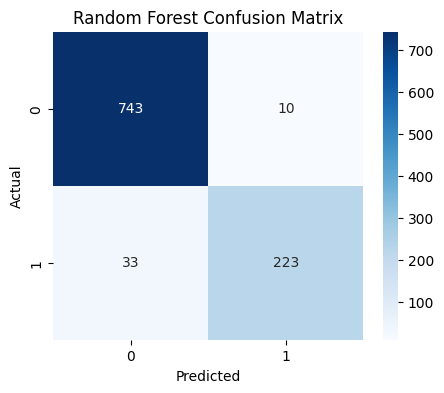

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

In [34]:
from sklearn.ensemble import ExtraTreesClassifier

In [35]:
def et_objective(trial):

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators",
            100,
            300,
            step=50
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            5,
            30
        ),

        "min_samples_split": trial.suggest_int(
            "min_samples_split",
            2,
            10
        ),

        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf",
            1,
            5
        ),

        "max_features": trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2"]
        ),

        "bootstrap": trial.suggest_categorical(
            "bootstrap",
            [True, False]
        ),

        "criterion": trial.suggest_categorical(
            "criterion",
            ["gini", "entropy", "log_loss"]
        ),

        "class_weight": trial.suggest_categorical(
            "class_weight",
            [None, "balanced"]
        ),

        "random_state":42,

        "n_jobs":-1
    }

    model = ExtraTreesClassifier(**params)

    score = cross_val_score(

        model,

        X_train,

        y_train,

        cv=inner_cv,

        scoring="f1",

        n_jobs=-1

    ).mean()

    return score

In [36]:
study = optuna.create_study(

    direction="maximize",

    pruner=optuna.pruners.MedianPruner()

)

study.optimize(

    et_objective,

    n_trials=10,

    show_progress_bar=True

)

[I 2026-08-03 07:29:36,552] A new study created in memory with name: no-name-cf5b4cfb-135b-4458-b8c1-51c47bc590a9


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-08-03 07:29:41,074] Trial 0 finished with value: 0.6507447881499389 and parameters: {'n_estimators': 200, 'max_depth': 6, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini', 'class_weight': None}. Best is trial 0 with value: 0.6507447881499389.
[I 2026-08-03 07:29:45,415] Trial 1 finished with value: 0.7277809779668938 and parameters: {'n_estimators': 250, 'max_depth': 8, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'log_loss', 'class_weight': None}. Best is trial 1 with value: 0.7277809779668938.
[I 2026-08-03 07:29:52,642] Trial 2 finished with value: 0.878874571410871 and parameters: {'n_estimators': 200, 'max_depth': 27, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini', 'class_weight': 'balanced'}. Best is trial 2 with value: 0.878874571410871.
[I 2026-08-03 07:29:57,892] Trial 3 finished with val

In [37]:
print("="*60)

print("Best F1 Score")

print(study.best_value)

print("\nBest Parameters")

print(study.best_params)

Best F1 Score
0.886992531733837

Best Parameters
{'n_estimators': 200, 'max_depth': 28, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'entropy', 'class_weight': None}


In [38]:
best_params = study.best_params

best_params["random_state"] = 42

best_params["n_jobs"] = -1

et_model = ExtraTreesClassifier(

    **best_params

)

et_model.fit(

    X_train,

    y_train

)

ExtraTreesClassifier(criterion='entropy', max_depth=28, min_samples_leaf=2,
                     min_samples_split=3, n_estimators=200, n_jobs=-1,
                     random_state=42)

In [39]:
et_pred = et_model.predict(X_test)
et_prob = et_model.predict_proba(X_test)[:, 1]
y_pred, y_prob = et_pred, et_prob


In [40]:
et_results = {
    "Model": "Extra Trees",
    "Accuracy": accuracy_score(y_test, et_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_test, et_pred),
    "Precision": precision_score(y_test, et_pred, zero_division=0),
    "Recall": recall_score(y_test, et_pred, zero_division=0),
    "F1-score": f1_score(y_test, et_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, et_prob),
    "PR-AUC": average_precision_score(y_test, et_prob)
}
print(pd.Series(et_results))


Model                Extra Trees
Accuracy                0.961348
Balanced Accuracy       0.927695
Precision               0.986547
Recall                  0.859375
F1-score                 0.91858
ROC-AUC                 0.987322
PR-AUC                  0.970688
dtype: object


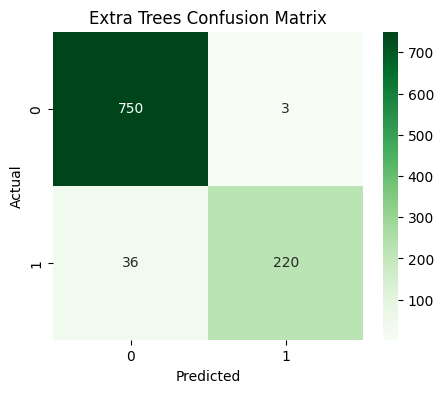

In [41]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Greens"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Extra Trees Confusion Matrix")

plt.show()

In [42]:
print("Extra Trees results stored for final comparison.")


Extra Trees results stored for final comparison.


In [43]:
from xgboost import XGBClassifier

In [44]:
def xgb_objective(trial):

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators",
            100,
            300,
            step=50
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            10
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.3,
            log=True
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "gamma": trial.suggest_float(
            "gamma",
            0,
            5
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            10
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-5,
            10,
            log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-5,
            10,
            log=True
        ),

        "objective": "binary:logistic",

        "eval_metric": "logloss",

        "random_state": 42,

        "n_jobs": -1,

        "tree_method": "hist",

        "verbosity": 0
    }

    model = XGBClassifier(**params)

    score = cross_val_score(

        model,

        X_train,

        y_train,

        cv=inner_cv,

        scoring="f1",

        n_jobs=-1

    ).mean()

    return score

In [45]:
study = optuna.create_study(

    direction="maximize",

    pruner=optuna.pruners.MedianPruner()

)

study.optimize(

    xgb_objective,

    n_trials=10,

    show_progress_bar=True

)

[I 2026-08-03 07:30:32,578] A new study created in memory with name: no-name-ad0fa0d8-bf6c-42f3-871a-293858fb9b5a


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-08-03 07:30:33,538] Trial 0 finished with value: 0.8707059258805847 and parameters: {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.10782358500534377, 'subsample': 0.6300979644970243, 'colsample_bytree': 0.697729284778681, 'gamma': 0.002291395680008579, 'min_child_weight': 8, 'reg_alpha': 0.00018384441699105804, 'reg_lambda': 0.4802461452717481}. Best is trial 0 with value: 0.8707059258805847.
[I 2026-08-03 07:30:35,261] Trial 1 finished with value: 0.8890717485186492 and parameters: {'n_estimators': 250, 'max_depth': 9, 'learning_rate': 0.09309412863945829, 'subsample': 0.7085934885814272, 'colsample_bytree': 0.6976695746957241, 'gamma': 0.7987263825541108, 'min_child_weight': 8, 'reg_alpha': 0.010066499508742778, 'reg_lambda': 2.4648465105129165}. Best is trial 1 with value: 0.8890717485186492.
[I 2026-08-03 07:30:37,421] Trial 2 finished with value: 0.890682900335525 and parameters: {'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.09642401023097415, 'subsamp

In [46]:
print("="*60)

print("Best F1 Score")

print(study.best_value)

print("\nBest Parameters")

print(study.best_params)

Best F1 Score
0.890682900335525

Best Parameters
{'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.09642401023097415, 'subsample': 0.955631885768591, 'colsample_bytree': 0.9899431920769256, 'gamma': 0.3087169847755372, 'min_child_weight': 10, 'reg_alpha': 1.4020354950395362, 'reg_lambda': 1.0220541762368571}


In [47]:
best_params = study.best_params

best_params["objective"] = "binary:logistic"
best_params["eval_metric"] = "logloss"
best_params["random_state"] = 42
best_params["n_jobs"] = -1
best_params["tree_method"] = "hist"
best_params["verbosity"] = 0

xgb_model = XGBClassifier(

    **best_params

)

xgb_model.fit(

    X_train,

    y_train

)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9899431920769256, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=0.3087169847755372, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.09642401023097415,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=9, max_leaves=None,
              min_child_weight=10, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [48]:
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
y_pred, y_prob = xgb_pred, xgb_prob


In [49]:
print("="*60)

print("XGBoost Performance")

print("="*60)

print("Accuracy :", accuracy_score(y_test,y_pred))

print("Precision:", precision_score(y_test,y_pred))

print("Recall   :", recall_score(y_test,y_pred))

print("F1 Score :", f1_score(y_test,y_pred))

print("ROC AUC  :", roc_auc_score(y_test,y_prob))

XGBoost Performance
Accuracy : 0.9633300297324083
Precision: 0.974025974025974
Recall   : 0.87890625
F1 Score : 0.9240246406570842
ROC AUC  : 0.9861180278884463


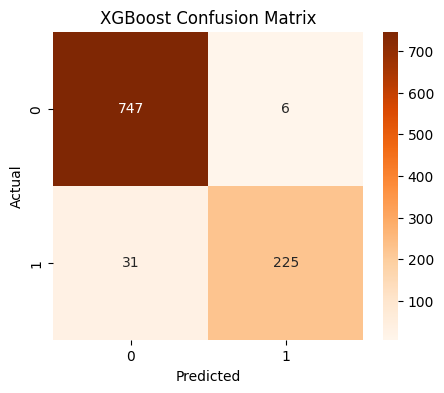

In [50]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Oranges"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("XGBoost Confusion Matrix")

plt.show()

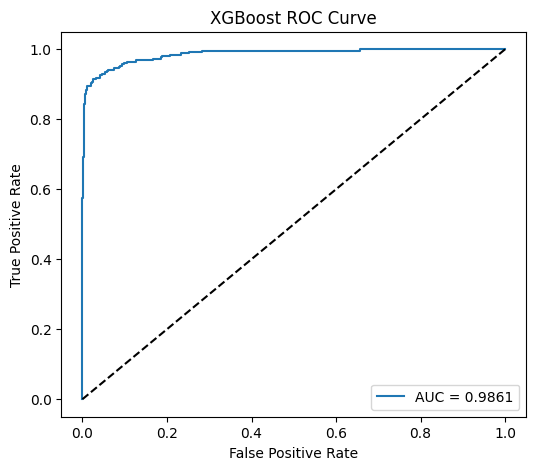

In [51]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.4f}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("XGBoost ROC Curve")

plt.legend()

plt.show()

In [52]:
xgb_results = {
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, xgb_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_test, xgb_pred),
    "Precision": precision_score(y_test, xgb_pred, zero_division=0),
    "Recall": recall_score(y_test, xgb_pred, zero_division=0),
    "F1-score": f1_score(y_test, xgb_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, xgb_prob),
    "PR-AUC": average_precision_score(y_test, xgb_prob)
}
print(pd.Series(xgb_results))


Model                 XGBoost
Accuracy              0.96333
Balanced Accuracy    0.935469
Precision            0.974026
Recall               0.878906
F1-score             0.924025
ROC-AUC              0.986118
PR-AUC                0.97192
dtype: object


In [53]:
from lightgbm import LGBMClassifier

In [54]:
def lgb_objective(trial):

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators",
            100,
            300,
            step=50
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.3,
            log=True
        ),

        "num_leaves": trial.suggest_int(
            "num_leaves",
            20,
            150
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            15
        ),

        "min_child_samples": trial.suggest_int(
            "min_child_samples",
            5,
            50
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-5,
            10,
            log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-5,
            10,
            log=True
        ),

        "random_state":42,

        "n_jobs":-1,

        "verbosity":-1
    }

    model = LGBMClassifier(**params)

    score = cross_val_score(

        model,

        X_train,

        y_train,

        cv=inner_cv,

        scoring="f1",

        n_jobs=-1

    ).mean()

    return score

In [55]:
study = optuna.create_study(

    direction="maximize",

    pruner=optuna.pruners.MedianPruner()

)

study.optimize(

    lgb_objective,

    n_trials=10,

    show_progress_bar=True

)

[I 2026-08-03 07:31:09,076] A new study created in memory with name: no-name-663175a3-1608-419b-850c-dddebbe1a081


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-08-03 07:31:32,508] Trial 0 finished with value: 0.900912528613112 and parameters: {'n_estimators': 250, 'learning_rate': 0.07105336271137794, 'num_leaves': 92, 'max_depth': 14, 'min_child_samples': 13, 'subsample': 0.8224538807008481, 'colsample_bytree': 0.9068197535088088, 'reg_alpha': 0.35280947693729225, 'reg_lambda': 1.695225492087462}. Best is trial 0 with value: 0.900912528613112.
[I 2026-08-03 07:31:38,396] Trial 1 finished with value: 0.8832031647443754 and parameters: {'n_estimators': 300, 'learning_rate': 0.06351035607466349, 'num_leaves': 118, 'max_depth': 3, 'min_child_samples': 7, 'subsample': 0.7995092891896524, 'colsample_bytree': 0.6445512860949348, 'reg_alpha': 0.26795499852913024, 'reg_lambda': 0.00012395842374175042}. Best is trial 0 with value: 0.900912528613112.
[I 2026-08-03 07:31:40,909] Trial 2 finished with value: 0.8907867392046152 and parameters: {'n_estimators': 250, 'learning_rate': 0.06778828764458361, 'num_leaves': 65, 'max_depth': 4, 'min_child_

In [56]:
print("="*60)

print("Best F1 Score")

print(study.best_value)

print("\nBest Parameters")

print(study.best_params)

Best F1 Score
0.9137447931455395

Best Parameters
{'n_estimators': 200, 'learning_rate': 0.07969634752888217, 'num_leaves': 110, 'max_depth': 14, 'min_child_samples': 32, 'subsample': 0.7421242119663829, 'colsample_bytree': 0.9862743412458935, 'reg_alpha': 1.454697141201531e-05, 'reg_lambda': 4.003192885584619e-05}


In [57]:
best_params = study.best_params

best_params["random_state"] = 42
best_params["n_jobs"] = -1
best_params["verbosity"] = -1

lgb_model = LGBMClassifier(

    **best_params

)

lgb_model.fit(

    X_train,

    y_train
)

LGBMClassifier(colsample_bytree=0.9862743412458935,
               learning_rate=0.07969634752888217, max_depth=14,
               min_child_samples=32, n_estimators=200, n_jobs=-1,
               num_leaves=110, random_state=42, reg_alpha=1.454697141201531e-05,
               reg_lambda=4.003192885584619e-05, subsample=0.7421242119663829,
               verbosity=-1)

In [58]:
lgb_pred = lgb_model.predict(X_test)
lgb_prob = lgb_model.predict_proba(X_test)[:, 1]
y_pred, y_prob = lgb_pred, lgb_prob


In [59]:
lgb_results = {
    "Model": "LightGBM",
    "Accuracy": accuracy_score(y_test, lgb_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_test, lgb_pred),
    "Precision": precision_score(y_test, lgb_pred, zero_division=0),
    "Recall": recall_score(y_test, lgb_pred, zero_division=0),
    "F1-score": f1_score(y_test, lgb_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, lgb_prob),
    "PR-AUC": average_precision_score(y_test, lgb_prob)
}
print(pd.Series(lgb_results))


Model                LightGBM
Accuracy             0.973241
Balanced Accuracy       0.955
Precision            0.975104
Recall               0.917969
F1-score             0.945674
ROC-AUC              0.990984
PR-AUC               0.983019
dtype: object


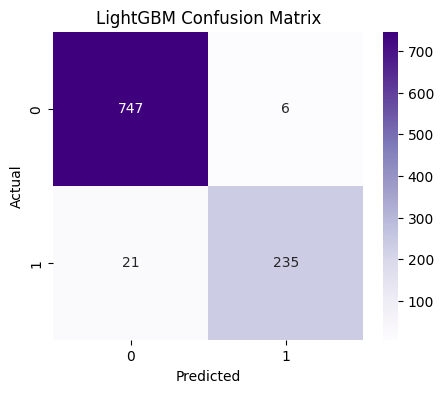

In [60]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("LightGBM Confusion Matrix")

plt.show()

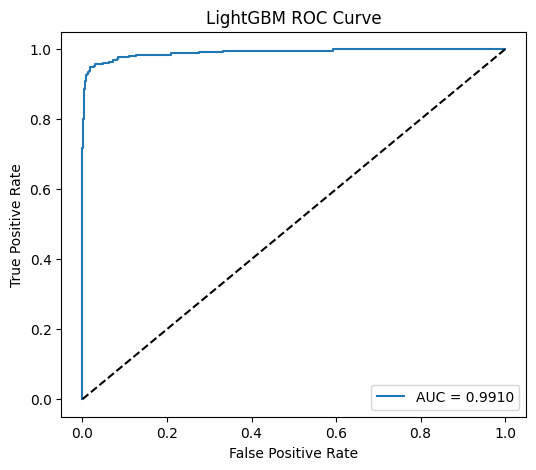

In [61]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y_test, y_prob):.4f}"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("LightGBM ROC Curve")

plt.legend()

plt.show()

In [62]:
from catboost import CatBoostClassifier

In [63]:
def cat_objective(trial):

    params = {

        "iterations": trial.suggest_int(
            "iterations",
            100,
            500,
            step=50
        ),

        "depth": trial.suggest_int(
            "depth",
            4,
            10
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.3,
            log=True
        ),

        "l2_leaf_reg": trial.suggest_float(
            "l2_leaf_reg",
            1,
            10
        ),

        "random_strength": trial.suggest_float(
            "random_strength",
            1e-3,
            10,
            log=True
        ),

        "bagging_temperature": trial.suggest_float(
            "bagging_temperature",
            0,
            10
        ),

        "border_count": trial.suggest_int(
            "border_count",
            32,
            255
        ),

        "loss_function":"Logloss",

        "eval_metric":"F1",

        "verbose":0,

        "random_seed":42
    }

    model = CatBoostClassifier(**params)

    score = cross_val_score(

        model,

        X_train,

        y_train,

        cv=inner_cv,

        scoring="f1",

        n_jobs=-1

    ).mean()

    return score

In [64]:
study = optuna.create_study(

    direction="maximize",

    pruner=optuna.pruners.MedianPruner()

)

study.optimize(

    cat_objective,

    n_trials=10,

    show_progress_bar=True

)

[I 2026-08-03 07:32:50,501] A new study created in memory with name: no-name-b631631d-b337-41a2-afe1-58f36f960a1b


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-08-03 07:32:53,668] Trial 0 finished with value: 0.8899572044424808 and parameters: {'iterations': 150, 'depth': 4, 'learning_rate': 0.23141604902099214, 'l2_leaf_reg': 6.468040542094414, 'random_strength': 8.981626202545005, 'bagging_temperature': 5.5614453461903155, 'border_count': 38}. Best is trial 0 with value: 0.8899572044424808.
[I 2026-08-03 07:33:40,942] Trial 1 finished with value: 0.9036348141776627 and parameters: {'iterations': 500, 'depth': 8, 'learning_rate': 0.15343265401949363, 'l2_leaf_reg': 8.211920630723323, 'random_strength': 0.14080219131456437, 'bagging_temperature': 6.424345142703896, 'border_count': 214}. Best is trial 1 with value: 0.9036348141776627.
[I 2026-08-03 07:33:46,024] Trial 2 finished with value: 0.8588797638928366 and parameters: {'iterations': 350, 'depth': 5, 'learning_rate': 0.01775644050396727, 'l2_leaf_reg': 5.061265656525517, 'random_strength': 0.7231757481829383, 'bagging_temperature': 0.7189436684090511, 'border_count': 92}. Best is

In [65]:
print("="*60)

print("Best F1 Score")

print(study.best_value)

print()

print("Best Parameters")

print(study.best_params)

Best F1 Score
0.9036348141776627

Best Parameters
{'iterations': 500, 'depth': 8, 'learning_rate': 0.15343265401949363, 'l2_leaf_reg': 8.211920630723323, 'random_strength': 0.14080219131456437, 'bagging_temperature': 6.424345142703896, 'border_count': 214}


In [66]:
best_params = study.best_params

best_params["loss_function"] = "Logloss"
best_params["eval_metric"] = "F1"
best_params["verbose"] = 0
best_params["random_seed"] = 42

cat_model = CatBoostClassifier(

    **best_params

)

cat_model.fit(

    X_train,

    y_train
)

CatBoostClassifier(bagging_temperature=6.424345142703896, border_count=214, depth=8, eval_metric='F1', iterations=500, l2_leaf_reg=8.211920630723323, learning_rate=0.15343265401949363, loss_function='Logloss', random_seed=42, random_strength=0.14080219131456437, verbose=0)

In [67]:
cat_pred = np.asarray(cat_model.predict(X_test)).astype(int).ravel()
cat_prob = cat_model.predict_proba(X_test)[:, 1]
y_pred, y_prob = cat_pred, cat_prob


In [68]:
cat_results = {
    "Model": "CatBoost",
    "Accuracy": accuracy_score(y_test, cat_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_test, cat_pred),
    "Precision": precision_score(y_test, cat_pred, zero_division=0),
    "Recall": recall_score(y_test, cat_pred, zero_division=0),
    "F1-score": f1_score(y_test, cat_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, cat_prob),
    "PR-AUC": average_precision_score(y_test, cat_prob)
}
print(pd.Series(cat_results))


Model                CatBoost
Accuracy             0.969277
Balanced Accuracy    0.945899
Precision            0.978723
Recall               0.898438
F1-score             0.936864
ROC-AUC              0.990061
PR-AUC               0.983368
dtype: object


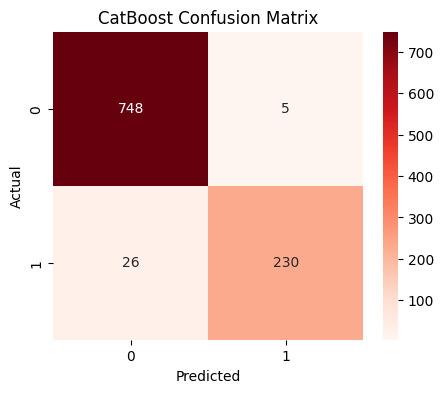

In [69]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Reds"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("CatBoost Confusion Matrix")

plt.show()

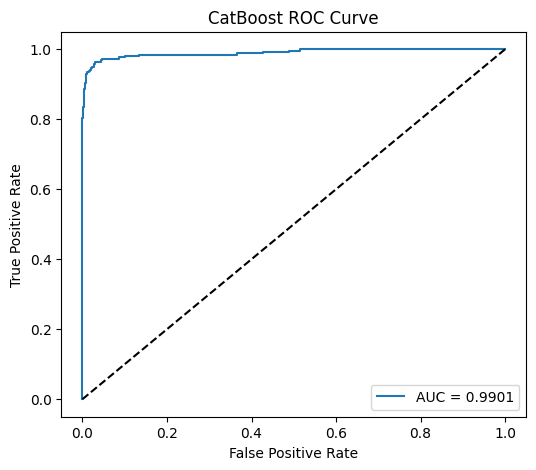

In [70]:
fpr, tpr, _ = roc_curve(y_test,y_prob)

plt.figure(figsize=(6,5))

plt.plot(

    fpr,

    tpr,

    label=f"AUC = {roc_auc_score(y_test,y_prob):.4f}"

)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("CatBoost ROC Curve")

plt.legend()

plt.show()

In [71]:
print("CatBoost results stored for final comparison.")


CatBoost results stored for final comparison.


In [72]:
# ============================================
# 7. MODEL-COMPARISON OUTPUT
# ============================================
results = pd.DataFrame([
    rf_results, et_results, xgb_results, lgb_results, cat_results
])
results = results.sort_values("F1-score", ascending=False).reset_index(drop=True)
results_rounded = results.round(4)
display(results_rounded)

results_rounded.to_csv("Model_Comparison.csv", index=False)


,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,LightGBM,0.9732,0.9550,0.9751,0.9180,0.9457,0.9910,0.9830
1,CatBoost,0.9693,0.9459,0.9787,0.8984,0.9369,0.9901,0.9834
2,XGBoost,0.9633,0.9355,0.9740,0.8789,0.9240,0.9861,0.9719
3,Extra Trees,0.9613,0.9277,0.9865,0.8594,0.9186,0.9873,0.9707
4,Random Forest,0.9574,0.9289,0.9571,0.8711,0.9121,0.9894,0.9753


In [73]:
print("Model ranking (highest F1-score first):")
display(results_rounded)


Model ranking (highest F1-score first):


,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,LightGBM,0.9732,0.9550,0.9751,0.9180,0.9457,0.9910,0.9830
1,CatBoost,0.9693,0.9459,0.9787,0.8984,0.9369,0.9901,0.9834
2,XGBoost,0.9633,0.9355,0.9740,0.8789,0.9240,0.9861,0.9719
3,Extra Trees,0.9613,0.9277,0.9865,0.8594,0.9186,0.9873,0.9707
4,Random Forest,0.9574,0.9289,0.9571,0.8711,0.9121,0.9894,0.9753


In [74]:
best_model_row = results.loc[results["F1-score"].idxmax()]
print("Best model by F1-score:")
print(best_model_row.round(4))


Best model by F1-score:
Model                LightGBM
Accuracy             0.973241
Balanced Accuracy       0.955
Precision            0.975104
Recall               0.917969
F1-score             0.945674
ROC-AUC              0.990984
PR-AUC               0.983019
Name: 0, dtype: object


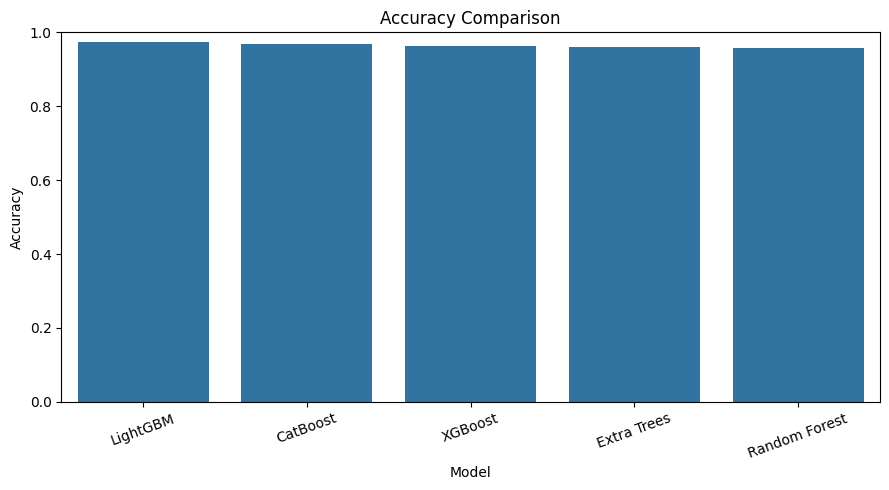

In [75]:
plt.figure(figsize=(9, 5))
sns.barplot(data=results_rounded, x="Model", y="Accuracy")
plt.ylim(0, 1)
plt.title("Accuracy Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


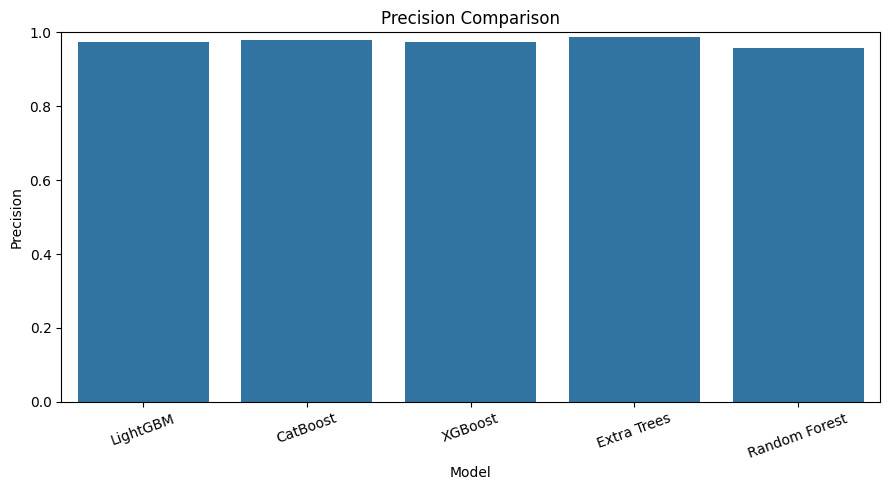

In [76]:
plt.figure(figsize=(9, 5))
sns.barplot(data=results_rounded, x="Model", y="Precision")
plt.ylim(0, 1)
plt.title("Precision Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


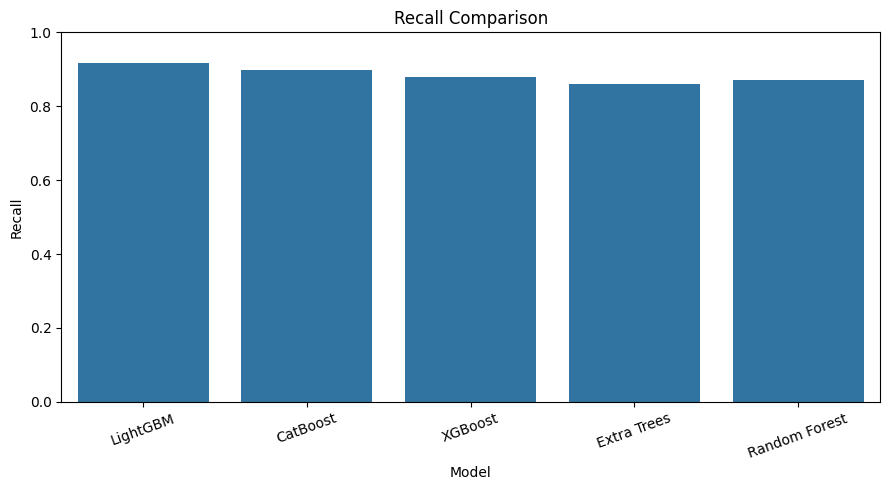

In [77]:
plt.figure(figsize=(9, 5))
sns.barplot(data=results_rounded, x="Model", y="Recall")
plt.ylim(0, 1)
plt.title("Recall Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


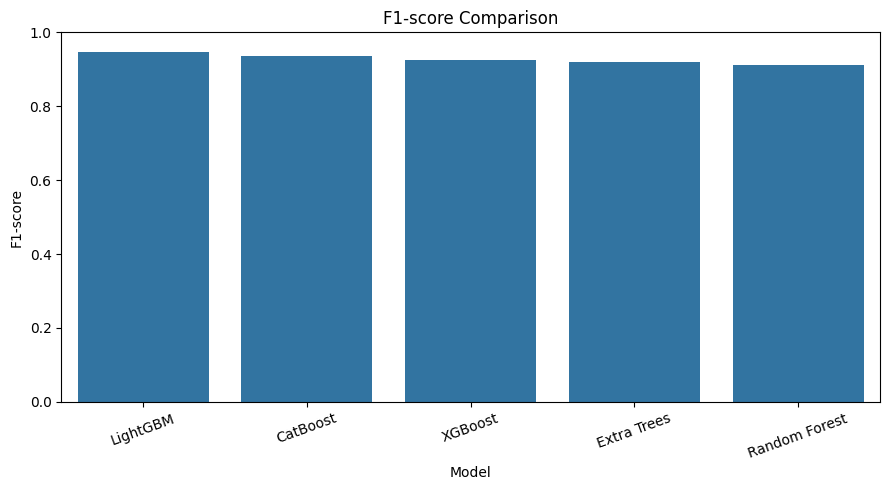

In [78]:
plt.figure(figsize=(9, 5))
sns.barplot(data=results_rounded, x="Model", y="F1-score")
plt.ylim(0, 1)
plt.title("F1-score Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


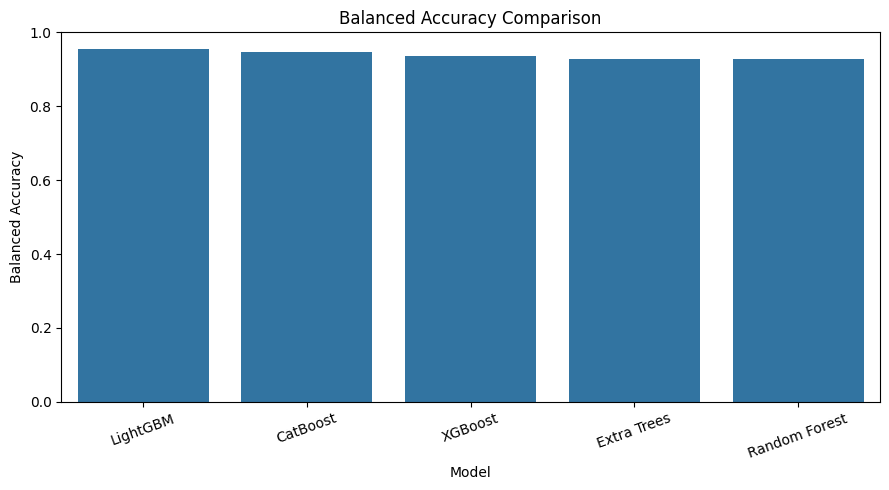

In [79]:
plt.figure(figsize=(9, 5))
sns.barplot(data=results_rounded, x="Model", y="Balanced Accuracy")
plt.ylim(0, 1)
plt.title("Balanced Accuracy Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


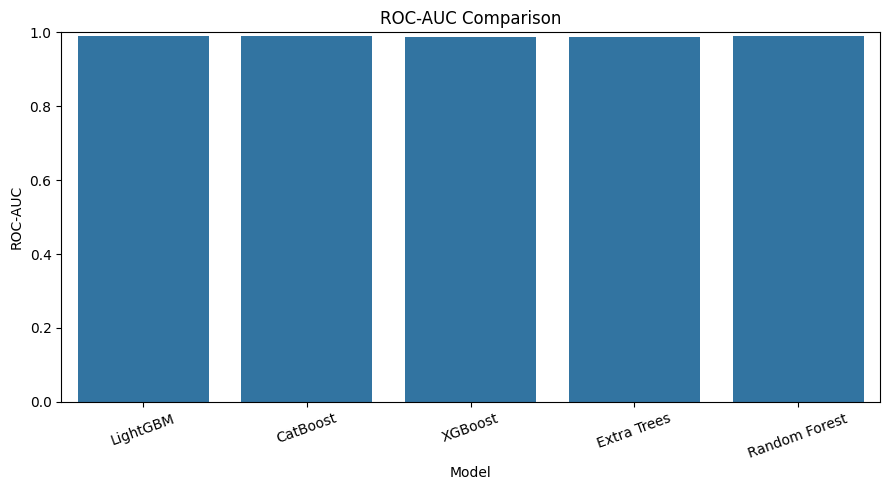

In [80]:
plt.figure(figsize=(9, 5))
sns.barplot(data=results_rounded, x="Model", y="ROC-AUC")
plt.ylim(0, 1)
plt.title("ROC-AUC Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [81]:
display(results_rounded.style.background_gradient(cmap="YlGn", subset=results_rounded.columns[1:]))


,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,LightGBM,0.973200,0.955000,0.975100,0.918000,0.945700,0.991000,0.983000
1,CatBoost,0.969300,0.945900,0.978700,0.898400,0.936900,0.990100,0.983400
2,XGBoost,0.963300,0.935500,0.974000,0.878900,0.924000,0.986100,0.971900
3,Extra Trees,0.961300,0.927700,0.986500,0.859400,0.918600,0.987300,0.970700
4,Random Forest,0.957400,0.928900,0.957100,0.871100,0.912100,0.989400,0.975300


In [82]:
results_rounded.to_csv("Ranked_Models.csv", index=False)
print("Saved: Ranked_Models.csv")


Saved: Ranked_Models.csv


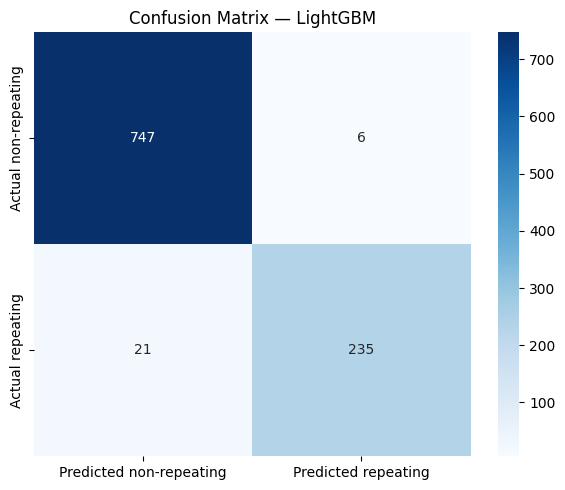

True negatives : 747
True positives : 235
False positives: 6
False negatives: 21


In [83]:
# ============================================
# 8. CONFUSION MATRIX OF THE BEST MODEL
# ============================================
prediction_map = {
    "Random Forest": rf_pred,
    "Extra Trees": et_pred,
    "XGBoost": xgb_pred,
    "LightGBM": lgb_pred,
    "CatBoost": cat_pred
}
probability_map = {
    "Random Forest": rf_prob,
    "Extra Trees": et_prob,
    "XGBoost": xgb_prob,
    "LightGBM": lgb_prob,
    "CatBoost": cat_prob
}
model_object_map = {
    "Random Forest": rf_model,
    "Extra Trees": et_model,
    "XGBoost": xgb_model,
    "LightGBM": lgb_model,
    "CatBoost": cat_model
}

best_model_name = best_model_row["Model"]
best_pred = prediction_map[best_model_name]
best_prob = probability_map[best_model_name]
best_estimator = model_object_map[best_model_name]

cm = confusion_matrix(y_test, best_pred)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Predicted non-repeating", "Predicted repeating"],
    yticklabels=["Actual non-repeating", "Actual repeating"]
)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()

print(f"True negatives : {tn}")
print(f"True positives : {tp}")
print(f"False positives: {fp}")
print(f"False negatives: {fn}")


In [84]:
# ============================================
# 9. SAMPLE EVENT-LEVEL PREDICTION OUTPUT
# ============================================
class_name = {0: "Non-repeating", 1: "Repeating"}

sample_predictions = pd.DataFrame({
    "FRB event": df.loc[X_test.index, event_id_col].astype(str).values,
    "Actual class": pd.Series(y_test.values).map(class_name),
    "Predicted class": pd.Series(best_pred).map(class_name),
    "Repeater probability": np.round(best_prob, 4)
}, index=X_test.index)

sample_predictions = sample_predictions.reset_index(drop=True)
display(sample_predictions.head(10))
sample_predictions.to_csv("FRB_Event_Predictions.csv", index=False)
print("Saved: FRB_Event_Predictions.csv")


,FRB event,Actual class,Predicted class,Repeater probability
0,FRB20221213I,NaN,NaN,0.0000
1,FRB20200122E,NaN,NaN,0.9672
2,FRB20200908B,NaN,NaN,0.0000
3,FRB20201222A,NaN,NaN,0.0001
4,FRB20190902E,Repeating,Repeating,0.0000
5,FRB20220319A,NaN,NaN,0.0000
6,FRB20230802B,NaN,NaN,0.0000
7,FRB20210125B,NaN,NaN,0.0012
8,FRB20210307B,NaN,NaN,0.0000
9,FRB20200506A,NaN,NaN,0.0000


Saved: FRB_Event_Predictions.csv


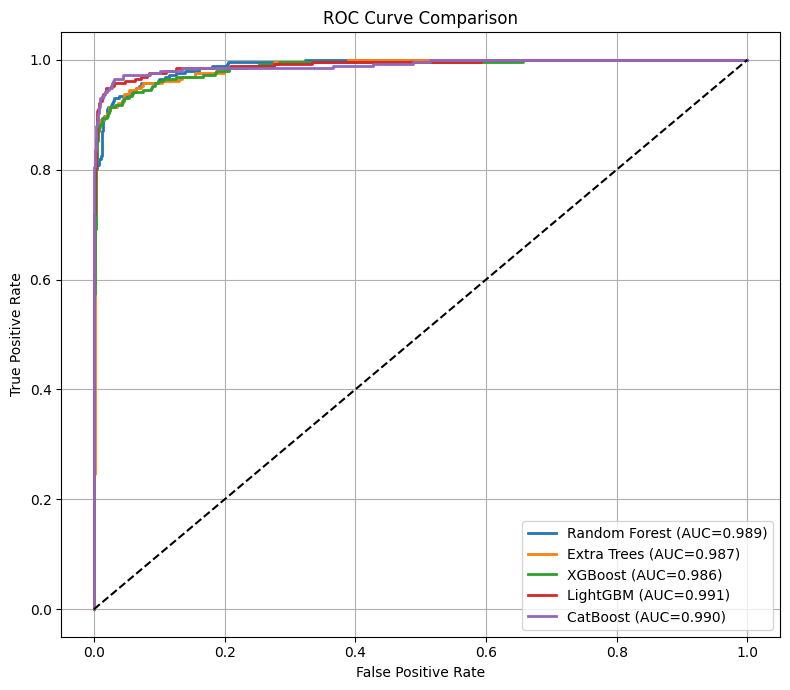

In [85]:
# Combined ROC curves for all models.
plt.figure(figsize=(8, 7))
for name, prob in probability_map.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


,Feature,Importance
16,gl,934
15,gb,905
20,ra,823
13,sp_run,808
21,dec,806
14,bc_width,727
19,mjd_inf,720
17,exp_up,718
0,dm_fitb,709
12,sp_idx,694


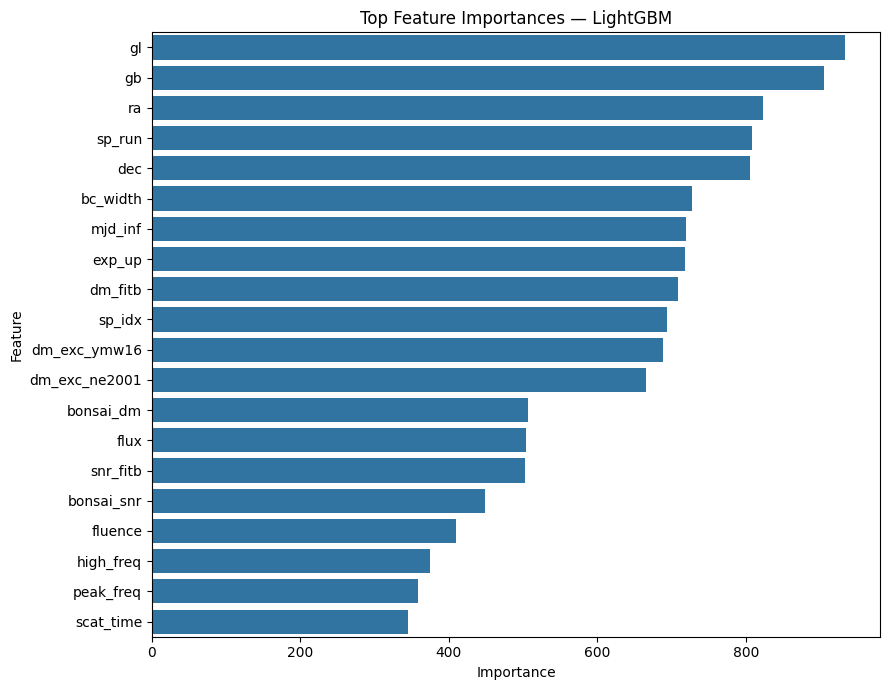

In [86]:
# ============================================
# 10. FEATURE IMPORTANCE OF THE BEST MODEL
# ============================================
if hasattr(best_estimator, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": best_estimator.feature_importances_
    }).sort_values("Importance", ascending=False)

    display(importance_df)
    plt.figure(figsize=(9, 7))
    sns.barplot(data=importance_df.head(20), x="Importance", y="Feature")
    plt.title(f"Top Feature Importances — {best_model_name}")
    plt.tight_layout()
    plt.show()
    importance_df.to_csv("Best_Model_Feature_Importance.csv", index=False)
else:
    print("Feature importance is not available for the selected estimator.")


In [87]:
# Final files created by this notebook:
# 1. Feature_Set_Comparison.csv
# 2. Model_Comparison.csv
# 3. Ranked_Models.csv
# 4. FRB_Event_Predictions.csv
# 5. Best_Model_Feature_Importance.csv
print("Notebook pipeline completed.")


Notebook pipeline completed.


In [88]:
from sklearn.model_selection import cross_val_score

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

rf_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

et_scores = cross_val_score(
    et_model,
    X_train,
    y_train,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

xgb_scores = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

lgb_scores = cross_val_score(
    lgb_model,
    X_train,
    y_train,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

cat_scores = cross_val_score(
    cat_model,
    X_train,
    y_train,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

In [89]:
stats_df = pd.DataFrame({

    "Model":[
        "Random Forest",
        "Extra Trees",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],

    "Mean F1":[
        rf_scores.mean(),
        et_scores.mean(),
        xgb_scores.mean(),
        lgb_scores.mean(),
        cat_scores.mean()
    ],

    "Std F1":[
        rf_scores.std(),
        et_scores.std(),
        xgb_scores.std(),
        lgb_scores.std(),
        cat_scores.std()
    ]

})

stats_df

,Model,Mean F1,Std F1
0,Random Forest,0.889892,0.019983
1,Extra Trees,0.879520,0.033212
2,XGBoost,0.887577,0.022005
3,LightGBM,0.918424,0.014708
4,CatBoost,0.911678,0.020065


In [90]:
from scipy.stats import friedmanchisquare

friedman_stat, friedman_p = friedmanchisquare(

    rf_scores,

    et_scores,

    xgb_scores,

    lgb_scores,

    cat_scores

)

print("Friedman Statistic :", friedman_stat)

print("P-value :", friedman_p)

Friedman Statistic : 25.840000000000003
P-value : 3.408431176453028e-05


In [91]:
alpha = 0.05

if friedman_p < alpha:

    print("Significant difference exists among classifiers.")

else:

    print("No statistically significant difference.")

Significant difference exists among classifiers.


In [92]:
from scipy.stats import wilcoxon
from itertools import combinations

scores = {

    "Random Forest": rf_scores,
    "Extra Trees": et_scores,
    "XGBoost": xgb_scores,
    "LightGBM": lgb_scores,
    "CatBoost": cat_scores

}

wilcoxon_results = []

for m1, m2 in combinations(scores.keys(), 2):

    stat, p = wilcoxon(

        scores[m1],

        scores[m2]

    )

    wilcoxon_results.append({

        "Model 1": m1,

        "Model 2": m2,

        "Statistic": stat,

        "P-value": p,

        "Significant": p < 0.05

    })

wilcoxon_df = pd.DataFrame(wilcoxon_results)

wilcoxon_df

,Model 1,Model 2,Statistic,P-value,Significant
0,Random Forest,Extra Trees,18.0,0.375000,False
1,Random Forest,XGBoost,23.0,0.695312,False
2,Random Forest,LightGBM,1.0,0.003906,True
3,Random Forest,CatBoost,1.0,0.003906,True
4,Extra Trees,XGBoost,15.0,0.232422,False
5,Extra Trees,LightGBM,0.0,0.001953,True
6,Extra Trees,CatBoost,1.0,0.003906,True
7,XGBoost,LightGBM,0.0,0.001953,True
8,XGBoost,CatBoost,0.0,0.001953,True
9,LightGBM,CatBoost,12.0,0.130859,False


In [93]:
stats_df.to_csv(
    "CrossValidation_Statistics.csv",
    index=False
)

wilcoxon_df.to_csv(
    "Wilcoxon_Test.csv",
    index=False
)

In [94]:
best_model = lgb_model

In [95]:
import shap

explainer = shap.TreeExplainer(best_model)

shap_values = explainer(X_test)

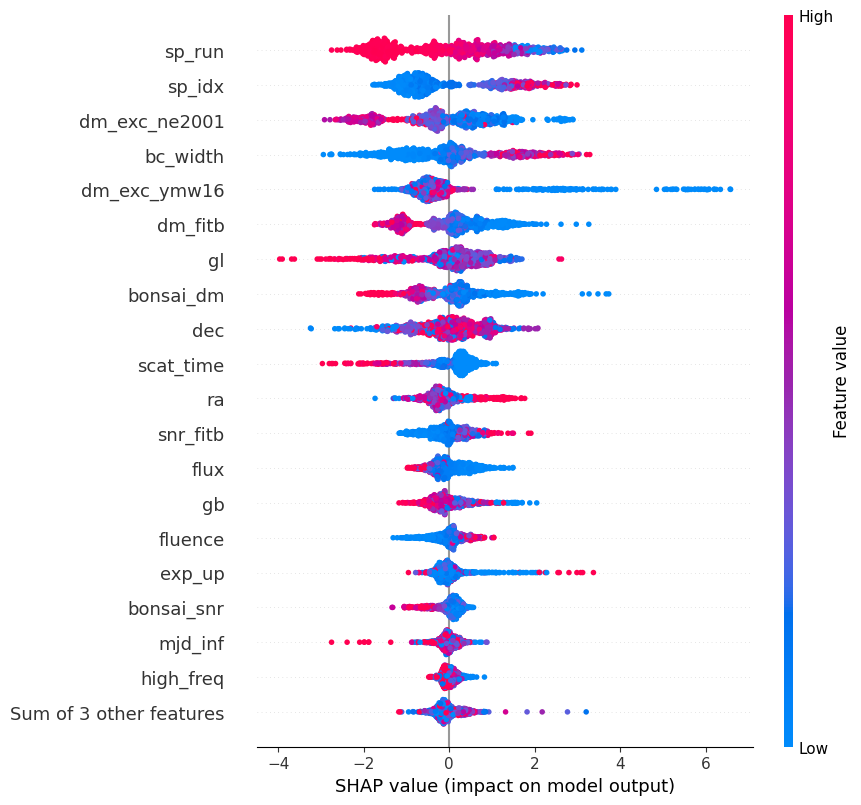

In [97]:
plt.figure(figsize=(10,6))

# Create a new Explanation object for the positive class (class 1)
positive_class_shap_values = shap.Explanation(
    values=shap_values.values, # Use values directly as it's already 2D
    base_values=shap_values.base_values, # Use base_values directly
    data=X_test # Keep the original data for feature names and values
)

shap.plots.beeswarm(
    positive_class_shap_values,
    max_display=20
)

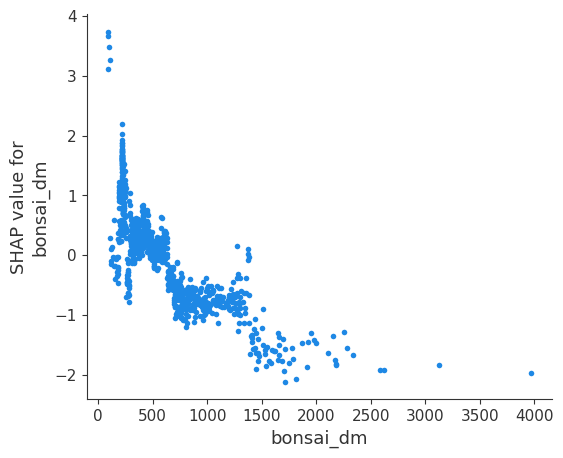

In [98]:
shap.dependence_plot(
    "bonsai_dm",
    positive_class_shap_values.values, # Pass the raw SHAP values (numpy array)
    X_test,                             # Pass the original feature data (DataFrame)
    interaction_index=None              # Keep interaction_index=None
)

In [99]:
shap.initjs()

shap.force_plot(
    positive_class_shap_values[0] # Pass the Explanation object for the first instance of the positive class
)

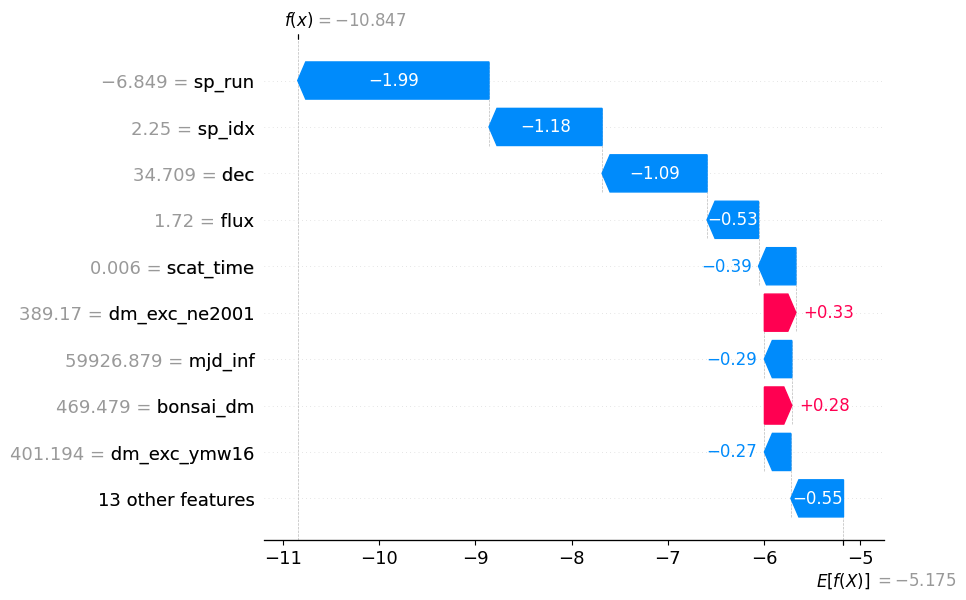

In [100]:
shap.plots.waterfall(
    positive_class_shap_values[0]
)

In [101]:
importance = pd.DataFrame({

    "Feature": X_test.columns,

    "Importance": np.abs(positive_class_shap_values.values).mean(axis=0)

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(20)

,Feature,Importance
13,sp_run,1.148832
12,sp_idx,1.040659
1,dm_exc_ne2001,0.904566
14,bc_width,0.902008
2,dm_exc_ymw16,0.857859
0,dm_fitb,0.704141
16,gl,0.683489
5,bonsai_dm,0.613756
21,dec,0.605158
8,scat_time,0.447962


In [102]:
importance.to_csv(

    "SHAP_Feature_Importance.csv",

    index=False

)